In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import hyperopt
from hyperopt import hp, fmin, tpe, Trials, partial
from hyperopt.early_stop import no_progress_loss
from lightgbm.callback import early_stopping
from sklearn.metrics import r2_score, mean_squared_error,explained_variance_score,mean_absolute_error
import pickle

In [2]:
data = pd.read_csv('micedata.csv',header = None)
data = data.values
# 分割输入和目标
X = data[:, 2:]  # 特征
y = data[:, :2]  # 预测目标
# 数据分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# 数据标准化
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train)
y_test = scaler.transform(y_test)

In [45]:

def train(params):
    print(params)
    model = lgb.LGBMRegressor(
        boosting_type='gbdt', # 提升类型，'gbdt' 表示传统的梯度提升决策树
        num_leaves=params['num_leaves'], # 树的叶子节点数量，较大的值可能导致更好的准确率，但也可能引起过拟合
        max_depth=params['max_depth'], # 树的最大深度，-1 表示没有限制
        learning_rate=params['learning_rate'], # 学习率，较小的值通常需要更多的树来训练
        n_estimators=100, # 提升树的数量，即训练过程中使用的树的数量
        objective='regression', # 训练目标，'regression' 表示回归任务
        subsample=params['subsample'], # 子样本的比例，用于防止过拟合
        colsample_bytree=params['colsample_bytree'], # 每次迭代中随机选择的特征比例
        reg_alpha=params['reg_alpha'], # L1 正则化项
        reg_lambda=params['reg_lambda'], # L2 正则化项
        random_state=1, # 随机数种子
        verbose = -1
    )
    # 训练模型
    model.fit(X_train, 
              y_train1  ,        
              eval_set=[(X_test, y_test1)], # 验证数据集
              callbacks=[early_stopping(stopping_rounds=10)],)
    return model.best_score_['valid_0']['l2']  
param_grid_simple = {'num_leaves':hp.randint('num_leaves',30)+3
                     ,'max_depth':hp.randint('max_depth',6)+1
                     ,'learning_rate': hp.uniform("learning_rate",0.00005,0.1)
                     # ,'min_child_samples':hp.randint('min_child_samples',25)+1
                     ,'subsample':hp.uniform("subsample",0.1,1)
                     ,'colsample_bytree': hp.uniform("colsample_bytree",0.1,1)
                    ,'reg_alpha': hp.uniform("reg_alpha",0.000001,0.1)
                    ,'reg_lambda': hp.uniform("reg_lambda",0.000001,0.1)
                    }

def param_hyperopt(max_evals=100):
    
    #保存迭代过程
    trials = Trials()
    
    #设置提前停止
    early_stop_fn = no_progress_loss(100)
    
    #定义代理模型
    #algo = partial(tpe.suggest, n_startup_jobs=20, n_EI_candidates=50)
    params_best = fmin(train #目标函数
                       , space = param_grid_simple #参数空间
                       , algo = tpe.suggest 
                       #, algo = algo
                       , max_evals = max_evals #允许的迭代次数
                       , verbose=True
                       , trials = trials
                       , early_stop_fn = early_stop_fn
                      )
    
    #打印最优参数，fmin会自动打印最佳分数
    print("\n","\n","best params: ", params_best,
          "\n")
    return params_best, trials
params_list = []
for i in range(2):
    y_train1 = y_train[:,i]
    y_test1 = y_test[:,i]
    params_best, trials = param_hyperopt(max_evals=100)
    params_list.append(params_best)

{'colsample_bytree': 0.8257146999685819, 'learning_rate': 0.030813436593658605, 'max_depth': 2, 'num_leaves': 17, 'reg_alpha': 0.08888913955227912, 'reg_lambda': 0.0964365255200373, 'subsample': 0.7274969721407303}
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:        
[98]	valid_0's l2: 0.866238
{'colsample_bytree': 0.9081891993685463, 'learning_rate': 0.07989510954944923, 'max_depth': 1, 'num_leaves': 17, 'reg_alpha': 0.08725209581138692, 'reg_lambda': 0.054546935093870465, 'subsample': 0.10149314714665746}
Training until validation scores don't improve for 10 rounds                     
Did not meet early stopping. Best iteration is:                                  
[100]	valid_0's l2: 0.887962
{'colsample_bytree': 0.6611259425089147, 'learning_rate': 0.076732036263392, 'max_depth': 3, 'num_leaves': 15, 'reg_alpha': 0.03159105170946864, 'reg_lambda': 0.010335407171198577, 'subsample': 0.6107355973425933}
Training until v

In [51]:
n_es = [100,72]
for i in range(2):
    params = params_list[i]
    y_train1 = y_train[:,i]
    y_test1 = y_test[:,i]
    model = lgb.LGBMRegressor(
        boosting_type='gbdt', # 提升类型，'gbdt' 表示传统的梯度提升决策树
        num_leaves=params['num_leaves']+3, # 树的叶子节点数量，较大的值可能导致更好的准确率，但也可能引起过拟合
        max_depth=params['max_depth']+1, # 树的最大深度，-1 表示没有限制
        learning_rate=params['learning_rate'], # 学习率，较小的值通常需要更多的树来训练
        n_estimators=n_es[i], # 提升树的数量，即训练过程中使用的树的数量
        objective='regression', # 训练目标，'regression' 表示回归任务
        subsample=params['subsample'], # 子样本的比例，用于防止过拟合
        colsample_bytree=params['colsample_bytree'], # 每次迭代中随机选择的特征比例
        reg_alpha=params['reg_alpha'], # L1 正则化项
        reg_lambda=params['reg_lambda'], # L2 正则化项
        random_state=1, # 随机数种子
        verbose = -1
    )
    # 训练模型
    model.fit(X_train, 
              y_train1  ,        
              eval_set=[(X_test, y_test1)], # 验证数据集
              callbacks=[early_stopping(stopping_rounds=10)],)
    #保存模型
    with open('lgbm_model_{}.pkl'.format(i), 'wb') as f:
        pickle.dump(model, f)

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's l2: 0.807542
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[72]	valid_0's l2: 0.864581


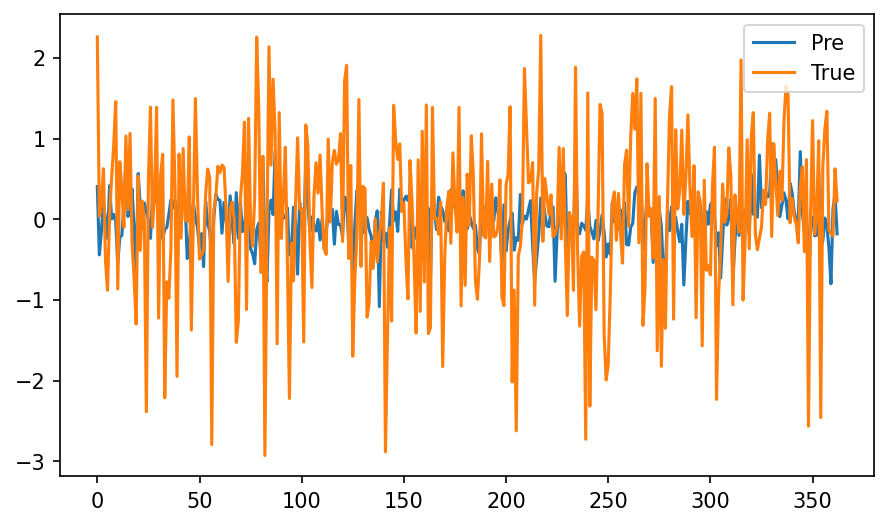

r2: 0.14385851587852527
ev: 0.14799109265608645
mse: 0.8075420322513261
rmse: 0.8986334248464867
mae: 0.7021778010634002
mape: 1.9579149643350608


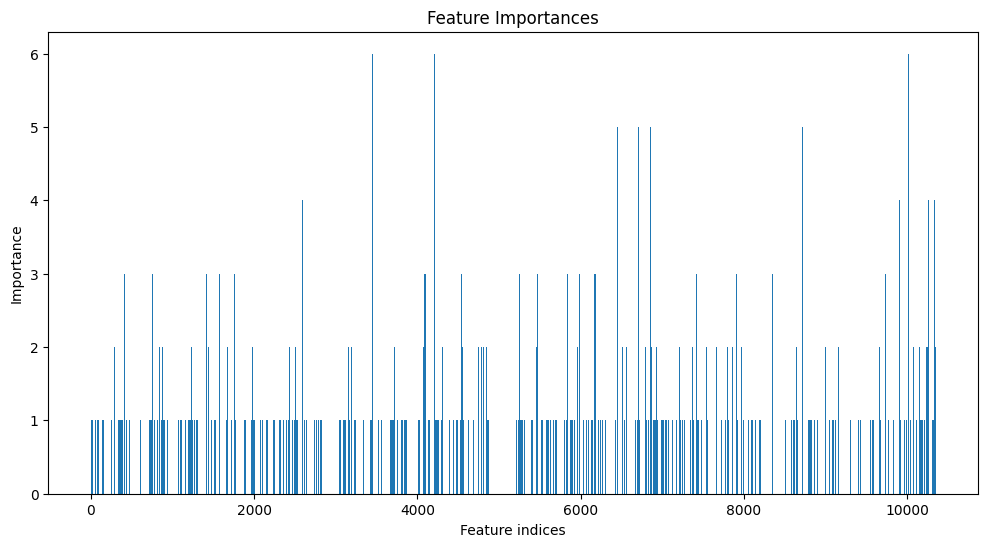

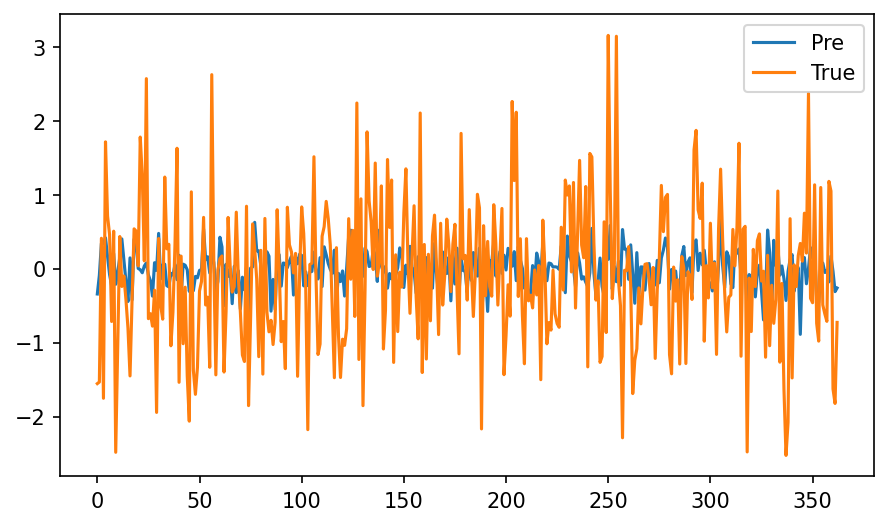

r2: 0.07565080342583808
ev: 0.0837704987915735
mse: 0.8645808745743457
rmse: 0.9298284113611208
mae: 0.7263049454939032
mape: 1.6326630407549734


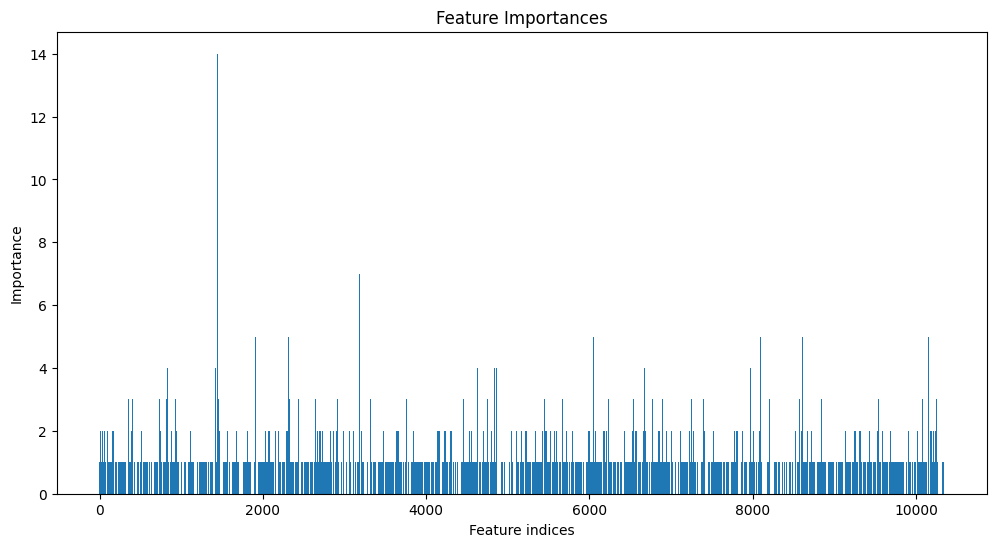

In [54]:
pred = []
for i in range(2):
    
    with open('lgbm_model_{}.pkl'.format(i), 'rb') as f:
        model = pickle.load(f)
    pre = model.predict(X_test)
    plt.figure(dpi=150,figsize=(7,4))
    plt.plot(pre.reshape(-1),label='Pre')
    plt.plot(y_test[:,i].reshape(-1),label = 'True')
    plt.legend()
    plt.show()
    Y_test1 = y_test[:,i]
    r2 = r2_score(Y_test1,pre)
    ev = explained_variance_score(Y_test1,pre)
    mse = mean_squared_error(Y_test1,pre)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(Y_test1,pre)

    pre = pre.reshape(-1)
    Y_test1 = Y_test1.reshape(-1)
    INDEX = []
    page = 0
    for i in Y_test1:
        if i ==0:
            INDEX.append(page)
        page +=1
    if INDEX !=[]:
        Y_test1 = np.delete(Y_test1,INDEX,0)
        pre     = np.delete(pre,INDEX,0)
    mape = (sum(abs((pre - Y_test1)/(Y_test1)))/len(Y_test1))
    print('r2:',r2)
    print('ev:',ev)
    print('mse:',mse)
    print('rmse:',rmse)
    print('mae:',mae)
    print('mape:',mape)
    # 获取特征重要性并可视化
    feature_importances = model.feature_importances_
    # 可视化特征重要性
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(feature_importances)), feature_importances,width=10)
    plt.xlabel('Feature indices')
    plt.ylabel('Importance')
    plt.title('Feature Importances')
    plt.show()
    
    pred.append(pre)
pred = np.array(pred)